In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score




In [30]:
df = fetch_california_housing()

In [31]:
df.data

array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
          37.88      , -122.23      ],
       [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
          37.86      , -122.22      ],
       [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
          37.85      , -122.24      ],
       ...,
       [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
          39.43      , -121.22      ],
       [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
          39.43      , -121.32      ],
       [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
          39.37      , -121.24      ]])

In [32]:
df.target

array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894])

In [33]:
X = df.data
y = df.target

In [34]:
df = pd.DataFrame(X, columns = df.feature_names)

In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
dtypes: float64(8)
memory usage: 1.3 MB


In [36]:
df["MedHouseVal"] = y

In [37]:
df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


In [38]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


(array([   9.,   14.,   61.,  255.,  538.,  676.,  546.,  803.,  881.,
         706.,  812.,  715.,  836.,  815.,  921.,  960.,  786.,  817.,
         703.,  505.,  620.,  661.,  578.,  508.,  432.,  439.,  463.,
         331.,  320.,  216.,  224.,  232.,  245.,  252.,  286.,  193.,
         160.,  149.,  117.,  133.,  104.,   99.,   80.,   90.,  106.,
          66.,   49.,   51.,   47., 1030.]),
 array([0.14999  , 0.2469904, 0.3439908, 0.4409912, 0.5379916, 0.634992 ,
        0.7319924, 0.8289928, 0.9259932, 1.0229936, 1.119994 , 1.2169944,
        1.3139948, 1.4109952, 1.5079956, 1.604996 , 1.7019964, 1.7989968,
        1.8959972, 1.9929976, 2.089998 , 2.1869984, 2.2839988, 2.3809992,
        2.4779996, 2.575    , 2.6720004, 2.7690008, 2.8660012, 2.9630016,
        3.060002 , 3.1570024, 3.2540028, 3.3510032, 3.4480036, 3.545004 ,
        3.6420044, 3.7390048, 3.8360052, 3.9330056, 4.030006 , 4.1270064,
        4.2240068, 4.3210072, 4.4180076, 4.515008 , 4.6120084, 4.7090088,
        

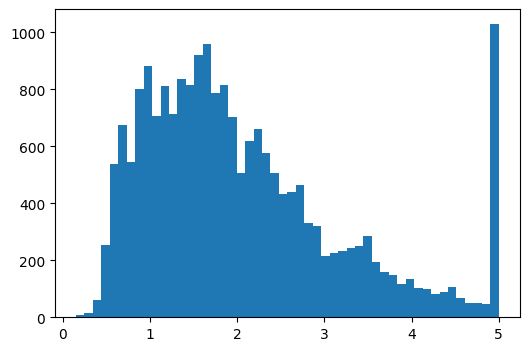

In [39]:
plt.figure(figsize =(6,4))
plt.hist(y, bins=50)

<Axes: >

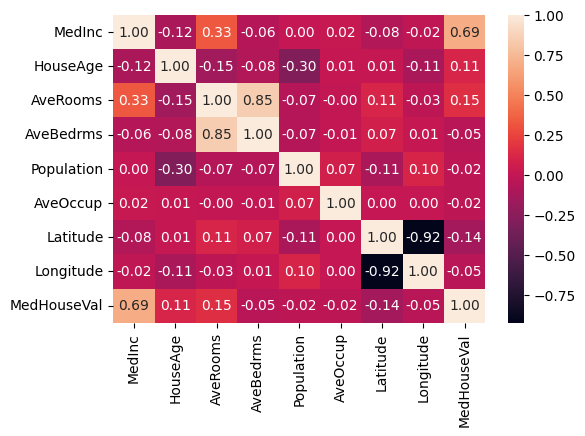

In [40]:
corr = df.corr()
plt.figure(figsize =(6,4))
sns.heatmap(corr, annot= True, fmt =".2f")

Text(0, 0.5, 'Lattitude')

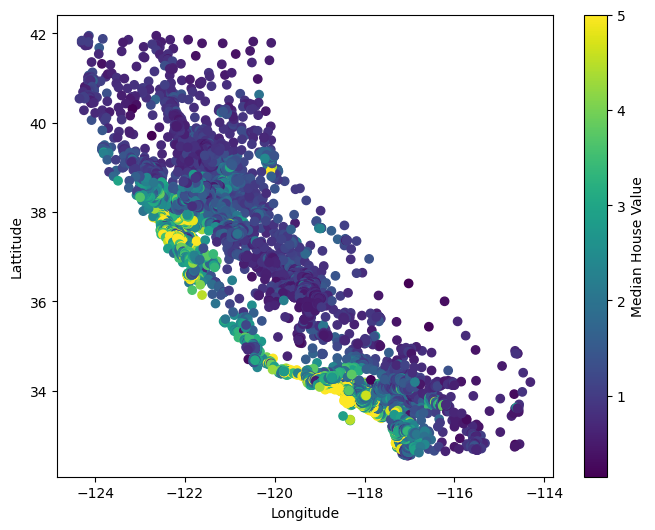

In [44]:
plt.figure(figsize =(8,6))
sc = plt.scatter(df["Longitude"], df["Latitude"], c = df["MedHouseVal"])
plt.colorbar(sc, label = "Median House Value")
plt.xlabel("Longitude")
plt.ylabel("Lattitude")


In [45]:
df["MedHouseVal"].describe()

,MedHouseVal
count,20640.000000
mean,2.068558
std,1.153956
min,0.149990
25%,1.196000
50%,1.797000
75%,2.647250
max,5.000010


In [47]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [48]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [51]:
X_train_t = torch.tensor(X_train, dtype = torch.float32)
X_test_t = torch.tensor(X_test, dtype =torch.float32)

In [53]:
y_train_t = torch.tensor(y_train, dtype = torch.float32).view(-1,1)
y_test_t = torch.tensor(y_test, dtype = torch.float32).view(-1,1)


In [75]:
class HousingDataset(Dataset):
  def __init__(self, X,y):
    self.X = X
    self.y = y

  def __len__(self):
    return len(self.X)

  def __getitem__ (self, idx):
    return self.X[idx], self.y[idx]


In [76]:
train_dataset = HousingDataset(X_train_t, y_train_t)
test_dataset = HousingDataset(X_test_t, y_test_t)

In [77]:
train_loader = DataLoader(train_dataset, batch_size =64, shuffle = True)
test_loader = DataLoader(test_dataset, batch_size =64, shuffle = False)


In [78]:

n_features = X_train_t.shape[1]


In [79]:
class HousingNN(nn.Module):
  def __init__(self, n_features):
    super().__init__()
    self.net = nn.Sequential(
        nn.Linear(n_features,64),
        nn.ReLU(),
        nn.Linear(64,32),
        nn.ReLU(),
        nn.Linear(32,16),
        nn.ReLU(),
        nn.Linear(16,1)
        # No Sigmoid Here
    )
  def forward(self, x):
    return self.net(x)


In [80]:
model = HousingNN(n_features)

In [81]:
total_parms = sum(p.numel() for p in model.parameters())

In [82]:
total_parms

3201

In [83]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr = 0.001)

In [90]:
num_epochs = 100
train_losses = []
val_losses = []



for epoch in range(num_epochs):
  model.train()

  epoch_loss = 0.0


  for X_batch, y_batch in train_loader:
    optimizer.zero_grad()
    predictions = model(X_batch)
    loss = criterion(predictions, y_batch)
    loss.backward()
    optimizer.step()

    epoch_loss += loss.item() * X_batch.size(0)
  epoch_loss /= len(train_dataset)

  train_losses.append(epoch_loss)

  model.eval()
  with torch.no_grad():
    val_pred = model(X_test_t)
    val_loss =  criterion(val_pred, y_test_t).item()

  val_losses.append(val_loss)

  if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{num_epochs} - Train MSE: {epoch_loss:.4f} - Val MSE: {val_loss:.4f}")








Epoch 10/100 - Train MSE: 0.2452 - Val MSE: 0.2736
Epoch 20/100 - Train MSE: 0.2385 - Val MSE: 0.2730
Epoch 30/100 - Train MSE: 0.2340 - Val MSE: 0.2717
Epoch 40/100 - Train MSE: 0.2293 - Val MSE: 0.2721
Epoch 50/100 - Train MSE: 0.2255 - Val MSE: 0.2727
Epoch 60/100 - Train MSE: 0.2196 - Val MSE: 0.2604
Epoch 70/100 - Train MSE: 0.2170 - Val MSE: 0.2684
Epoch 80/100 - Train MSE: 0.2154 - Val MSE: 0.2699
Epoch 90/100 - Train MSE: 0.2131 - Val MSE: 0.2688
Epoch 100/100 - Train MSE: 0.2105 - Val MSE: 0.2751


#

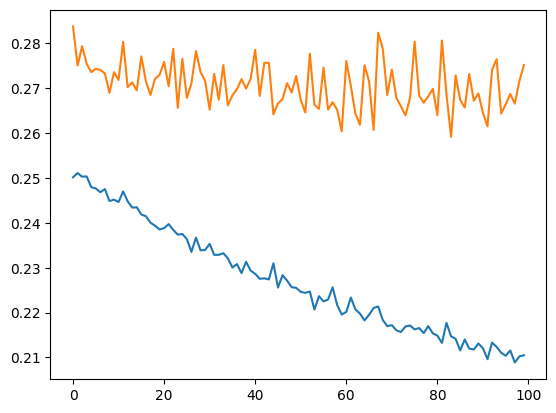

In [92]:
plt.plot(train_losses, label ="Train")
plt.plot(val_losses, label ="Validation")


In [94]:
model.eval()
with torch.no_grad():
    test_predictions = model(X_test_t)
    test_loss = criterion(test_predictions, y_test_t)

In [95]:
print(f"Test MSE: {test_loss.item():.4f}")


Test MSE: 0.2751


In [96]:
y_pred = test_predictions.numpy().flatten()
y_true = y_test_t.numpy().flatten()

rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae = mean_absolute_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)

print(f"RMSE: {rmse:.4f}  (~${rmse*100000:,.0f} average error)")
print(f"MAE:  {mae:.4f}  (~${mae*100000:,.0f} average absolute error)")
print(f"R²:   {r2:.4f}  ({r2*100:.1f}% of variance explained)")

RMSE: 0.5245  (~$52,454 average error)
MAE:  0.3435  (~$34,353 average absolute error)
R²:   0.7900  (79.0% of variance explained)


In [97]:
import os

os.makedirs("models", exist_ok = True)
torch.save(model.state_dict(), "models/housing_dict.pt")


torch.save(model, "models/housing_full.pt")


In [98]:
import joblib
joblib.dump(scaler, "models/scaler.joblib")


['models/scaler.joblib']